# **<font color ="#004AAD">[GLAMIFY](https://www.kaggle.com/datasets/zalando-research/fashionmnist/data)**
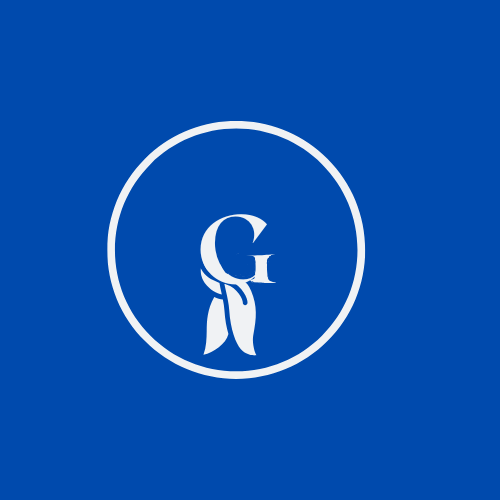

In [ ]:
!pip install tensorflow keras opencv-python numpy


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
from PIL import Image as Img
from IPython.display import Image, display
import os
import shutil
import kagglehub
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.utils import plot_model
from tensorflow.keras.datasets import fashion_mnist
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **<font color ="#004AAD"> Loading data**

In [ ]:
raw_data = np.genfromtxt(r'/content/fashion-mnist_train.csv', delimiter = ',', skip_header=1)
raw_test = np.genfromtxt( r'/content/fashion-mnist_test.csv', delimiter = ',', skip_header=1)
print("Shape data: ", raw_data.shape)
print("Shape test: ", raw_test.shape)

Shape data:  (60000, 785)
Shape test:  (10000, 785)


# **<font color ="#004AAD">First Look**

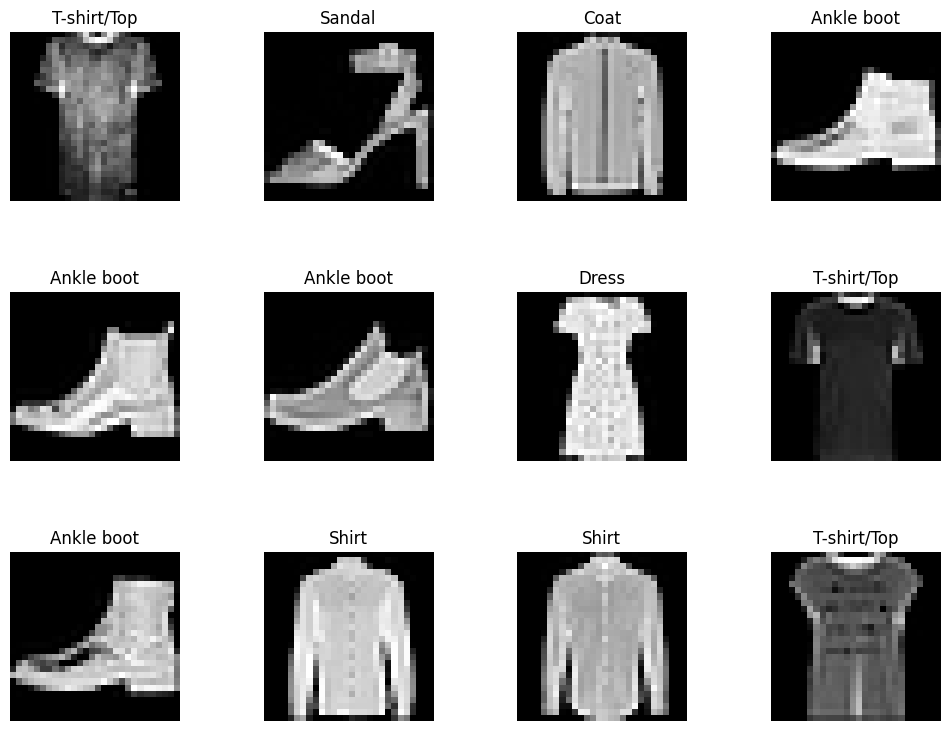

In [ ]:
input_image = raw_data[:,1:]
target_image = raw_data[:,0]

reshaped_input = input_image.reshape(-1, 28, 28)

df = pd.Series(target_image)
labels = df.map({
    0: 'T-shirt/Top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'})

fig, axs = plt.subplots(3, 4, figsize=(12, 9))
fig.subplots_adjust(hspace=0.5, wspace=0.5)
N = len(reshaped_input)

random_indices = np.random.choice(N, size=12, replace=False)

for i in range(3):
    for j in range(4):
        n = random_indices[i * 4 + j]
        axs[i, j].imshow(reshaped_input[n], cmap='gray')
        axs[i, j].set_title(labels[n])
        axs[i, j].axis('off')

plt.show()

In [ ]:
columns = ['Label'] + [str(i) for i in range(1, 785)]
data_df = pd.DataFrame(raw_data, columns=columns)
data_df

,Label,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59996,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,73.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,160.0,162.0,163.0,135.0,94.0,0.0,0.0,0.0,0.0,0.0
59998,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
classi = pd.Series(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])
classi

,0
0,T-shirt/top
1,Trouser
2,Pullover
3,Dress
4,Coat
5,Sandal
6,Shirt
7,Sneaker
8,Bag
9,Ankle boot


# **<font color ="#004AAD">Sample**

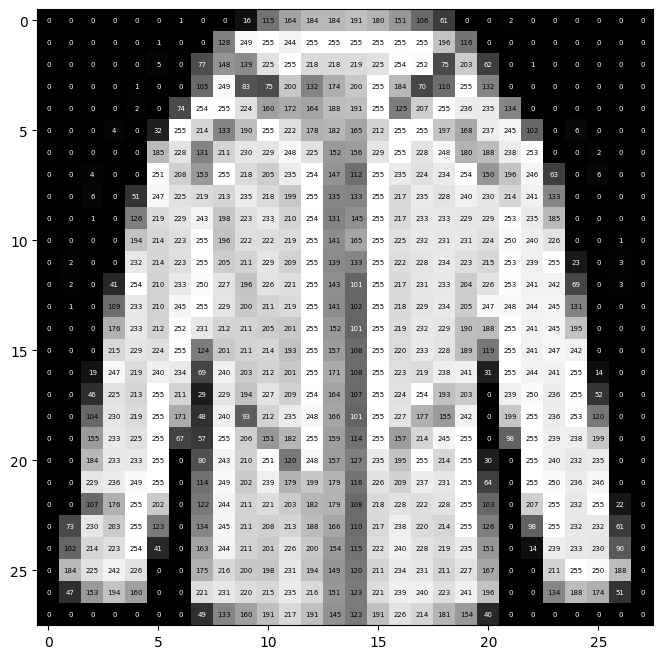

In [ ]:
def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    height, width = img.shape

    thresh = img.max()/2.5 # color of the text on the pixel
    for x in range(height):
        for y in range(width):
            ax.annotate(str(int(img[x][y])), xy=(y,x),
                        fontsize=5,
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y] < thresh else 'black')

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
visualize_input(reshaped_input[12989], ax)
plt.show()

In [ ]:
print(np.unique(raw_data[:,0]))
print(np.mean(raw_data[:,0]))

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
4.5


# **<font color ="#004AAD"> Data Shuffle**

In [ ]:
shuffled_indices = np.arange(raw_data.shape[0])
np.random.shuffle(shuffled_indices)
shuffled_data = raw_data[shuffled_indices]

In [ ]:
data_target = shuffled_data[:,0]
data_input = shuffled_data[:,1:]

In [ ]:
test_target = raw_test[:,0]
test_input = raw_test[:,1:]

# **<font color ="#004AAD">Split**

In [ ]:
samples_count = shuffled_data.shape[0]

train_samples_count = int(0.9*samples_count)
validation_samples_count = int(0.1*samples_count)

train_input = data_input[:train_samples_count]
train_target = data_target[:train_samples_count]

val_input = data_input[train_samples_count:train_samples_count+validation_samples_count]
val_target = data_target[train_samples_count:train_samples_count+validation_samples_count]

# **<font color ="#004AAD">Scalling**

In [ ]:
scaled_input = (train_input / 255).round(3)
scaled_val = (val_input / 255).round(3)
scaled_test = (test_input / 255).round(3)

# **<font color ="#004AAD">Modeling**

In [ ]:
input_size = 784
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Dense(hidden_layer_size, activation= 'relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation= 'relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation= 'relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
                          ])

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(784,), name='input'),
    tf.keras.layers.Dense(units=10, activation='relu', name='hidden_1'),
    tf.keras.layers.Dense(units=10, activation='relu', name='hidden_2'),
    tf.keras.layers.Dense(units=10, activation='relu', name='hidden_3'),
    tf.keras.layers.Dense(units=10, activation=tf.keras.activations.softmax, name='output'),
], name='model')

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
             )

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))
history = model.fit(data_input, data_target, epochs=50,
         validation_data=(test_input, test_target),
        callbacks=[lr_scheduler])

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 9.1009 - sparse_categorical_accuracy: 0.1303 - val_loss: 2.1872 - val_sparse_categorical_accuracy: 0.1949 - learning_rate: 1.0000e-04
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.1315 - sparse_categorical_accuracy: 0.2096 - val_loss: 1.9775 - val_sparse_categorical_accuracy: 0.2477 - learning_rate: 1.1220e-04
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.8834 - sparse_categorical_accuracy: 0.2669 - val_loss: 1.7067 - val_sparse_categorical_accuracy: 0.2984 - learning_rate: 1.2589e-04
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.6536 - sparse_categorical_accuracy: 0.3149 - val_loss: 1.4700 - val_sparse_categorical_accuracy: 0.3655 - learning_rate: 1.4125e-04
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.3722 - sparse_categorical_accuracy: 0.3784 - val_loss: 1.1791 - val_sparse_categorical_accuracy: 0.5329 - learning_rate: 1.5849e-04
Epoch 6/50
1875/1875

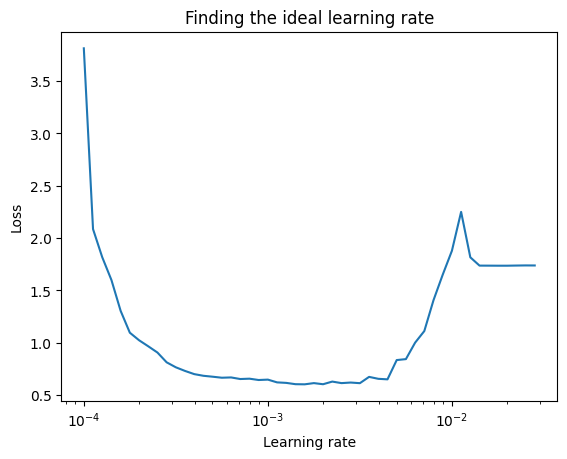

In [ ]:
lr = 1e-4 * 10**(np.arange(50)/20)
plt.semilogx(lr, history.history['loss'])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate");

# **<font color ="#004AAD">Evaluate**

<Axes: >

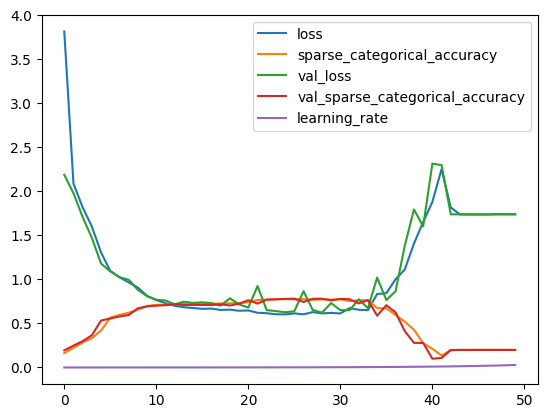

In [ ]:
pd.DataFrame(history.history).plot()

# **<font color ="#004AAD">Re-Modeling**

Model: "model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_3 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 125,898 (491.79 KB)

 Trainable params: 125,898 (491.79 KB)

 Non-trainable params: 0 (0.00 B)

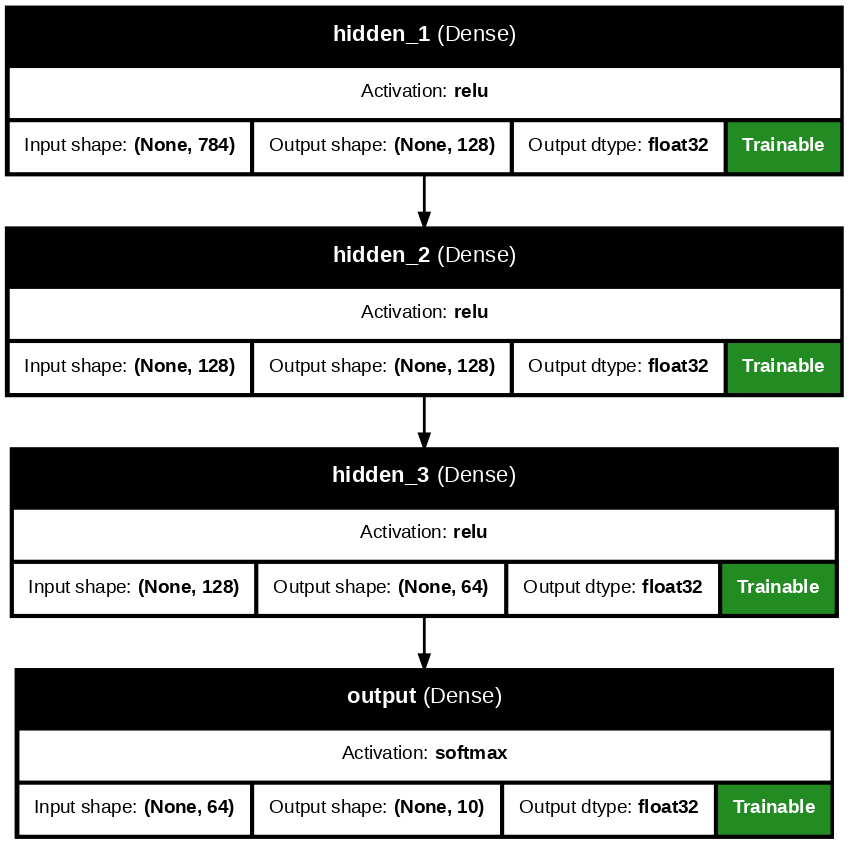

In [ ]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(784,), name='input'),
    tf.keras.layers.Dense(units=128, activation='relu', name='hidden_1'),
    tf.keras.layers.Dense(units=128, activation='relu', name='hidden_2'),
    tf.keras.layers.Dense(units=64, activation='relu', name='hidden_3'),
    tf.keras.layers.Dense(units=10, activation=tf.keras.activations.softmax, name='output'),
], name='model_2')

model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
             )

model_2.summary()
plot_model(model_2, show_shapes=True, show_dtype=True, show_layer_names=True,
           expand_nested=True, dpi=100, show_layer_activations=True,show_trainable=True,)

In [ ]:
history = model_2.fit(data_input, data_target, epochs=10,
         validation_split=0.15)

Epoch 1/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 3.8017 - sparse_categorical_accuracy: 0.7044 - val_loss: 0.6148 - val_sparse_categorical_accuracy: 0.8017
Epoch 2/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.5479 - sparse_categorical_accuracy: 0.8140 - val_loss: 0.4945 - val_sparse_categorical_accuracy: 0.8389
Epoch 3/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4911 - sparse_categorical_accuracy: 0.8295 - val_loss: 0.4652 - val_sparse_categorical_accuracy: 0.8418
Epoch 4/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4420 - sparse_categorical_accuracy: 0.8464 - val_loss: 0.5063 - val_sparse_categorical_accuracy: 0.8286
Epoch 5/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.4158 - sparse_categorical_accuracy: 0.8512 - val_loss: 0.4828 - val_sparse_categorical_accuracy: 0.8348
Epoch 6/10
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3969 - sparse_categorical_accuracy: 0.8577 - val_loss: 0.4158 - val_sparse_categorical_accuracy:

# **<font color ="#004AAD">Evaluate**

In [ ]:
model_2.evaluate(test_input, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3774 - sparse_categorical_accuracy: 0.8692


[0.38673144578933716, 0.8677999973297119]

In [ ]:
prob = model_2.predict(test_input) #Each row represents the probabilities for the 10 classes.
print('shape : ', prob.shape)
print(prob)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
shape :  (10000, 10)
[[6.0656488e-01 6.1855148e-06 1.4725188e-02 ... 6.5517917e-12
  1.1406563e-03 5.2567817e-10]
 [7.2604139e-23 9.9999994e-01 2.9846421e-21 ... 0.0000000e+00
  4.8797696e-23 0.0000000e+00]
 [6.6650160e-02 2.4606262e-03 4.6924990e-01 ... 4.5743076e-07
  2.1714082e-02 2.6653890e-06]
 ...
 [9.9884367e-18 1.3704570e-36 8.9145408e-21 ... 0.0000000e+00
  9.9999994e-01 0.0000000e+00]
 [1.4172546e-02 6.6726230e-08 3.8944001e-03 ... 9.8486441e-11
  9.6958005e-01 3.4946208e-09]
 [6.3375052e-04 9.9340302e-01 2.4593383e-04 ... 1.1505047e-16
  2.0059493e-05 1.6882272e-12]]


In [ ]:
pred = tf.argmax(prob, axis=1)
pred

<tf.Tensor: shape=(10000,), dtype=int64, numpy=array([0, 1, 2, ..., 8, 8, 1])>

# **<font color ="#004AAD">Confusion Matrix**

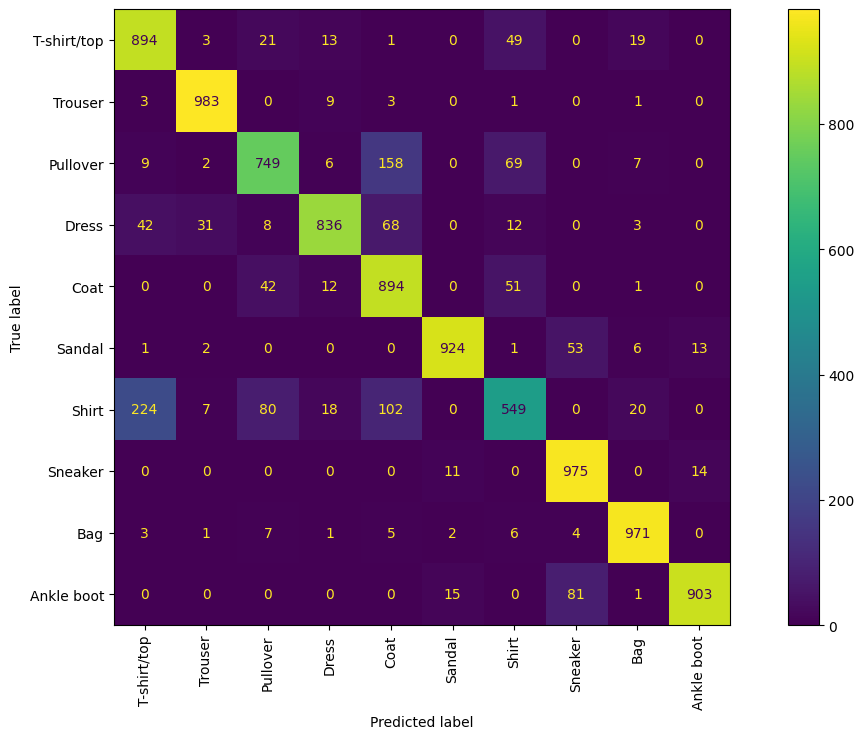

In [ ]:
cm = confusion_matrix(test_target, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classi)

fig, ax = plt.subplots(figsize=(15, 8))
disp.plot(ax=ax)

plt.xticks(rotation=90)

plt.show()

# **<font color ="#004AAD">Saving the model**

In [ ]:
keras_model = model_2.save('fashion_mnist_model.h5')
